In [1]:
from pathlib import Path
from astroquery.gaia import Gaia
from astropy.table import Table
import pandas as pd
import numpy as np
import sys
import os

from tqdm.auto import tqdm

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [ ]:
# Cargamos datos del ADQL
gaia_query_path = Path("services", "queries", "gaia_sdss_random_subset.adql")
gaia_query_template = gaia_query_path.read_text(encoding="utf-8")

# índices random
gaia_query = gaia_query_template.format(start_index=1, end_index=1500000)

gaia_query_job = Gaia.launch_job_async(gaia_query)
gaia_job_results = gaia_query_job.get_results() or Table()

display(gaia_job_results)

# Convertimos a panda/dataset
gaia_df = gaia_job_results.to_pandas()
# gaia_df.columns = [c.lower() for c in gaia_df.columns]

# Preprocesamos datos de Gaia

ispec_params = gaia_df.rename(columns={
    "teff_gspphot": "teff",
    "logg_gspphot": "logg",
    "mh_gspphot": "mh",
    "alphafe_gspspec": "alpha"
}).copy()

# Quitar filas no completas
ispec_params = ispec_params.dropna(
    subset=["source_id", "teff", "logg", "mh", "alpha"]
).reset_index(drop=True)

print("Filas con parámetros completos:", len(ispec_params))

############ Recomendación de CHATY tengo que mirar si es cierto
#ispec_params = ispec_params[
#    (ispec_params["teff"] >= 3500) &
#    (ispec_params["teff"] <= 8000) &
#    (ispec_params["logg"] >= 0.0) &
#    (ispec_params["logg"] <= 5.5) &
#    (ispec_params["mh"] >= -2.5) &
#    (ispec_params["mh"] <= 0.5)
#].reset_index(drop=True)

display(ispec_params[["source_id", "teff", "logg", "mh", "alpha"]].head())

# Guardamos datos en csv
params_output_dir = Path("data", "processed")
params_output_dir.mkdir(parents=True, exist_ok=True)

params_output_path = params_output_dir / "gaia_params_for_ispec.csv"
ispec_params.to_csv(params_output_path, index=False)

[2026-06-09 12:07:07,012] [INFO] [core:launch_job_async:481]: Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,phot_bp_mean_flux_over_error,phot_rp_mean_flux_over_error,astrometric_excess_noise,bp_rp,teff_gspphot,logg_gspphot,mh_gspphot,vbroad,alphafe_gspspec,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,,mas,mag,K,log(cm.s**-2),dex,km / s,dex,,arcsec
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32
2828636775059741824,341.9231323662956,15.755692305082151,11.538055,10.800761,1369.5103,3087.5913,0.103259966,0.7372942,5899.9653,4.207,-0.5261,--,0.13,1237680091651309699,0.19107537
3096062707589083136,120.38431429991603,6.27166537770808,9.748397,9.122459,2947.0962,3786.9988,1.4421897,0.62593746,6290.692,4.0279,-0.5836,10.24959,0.18,1237661069235257470,0.2629839
4463594175969472640,244.26868431465078,14.091361748167046,12.006538,11.279991,1483.6718,2541.9575,0.11416022,0.72654724,5970.3467,4.2678,-0.0828,--,0.0,1237665567156731982,0.03980958
595445023148260352,129.98469365348865,7.437678504445702,12.872434,12.146335,2020.4419,2699.183,0.033872426,0.726099,5935.591,4.2281,-1.1448,--,0.48,1237660670343839924,0.08191058
2558052250568143360,22.543293171697613,0.24357941511309059,11.380926,10.538818,1707.4062,2125.2214,0.16402228,0.8421078,5586.618,4.4757,-0.2471,7.7399106,0.27,1237657071156985971,0.1566968
2864059809891503872,5.425177369724694,34.335095892341414,12.867572,11.726737,1923.247,3944.3865,0.04680655,1.1408348,5071.415,4.065,0.3119,10.6186,0.3,1237680512018153535,0.068678185
1160923853313302656,223.76372779304944,6.9071165069230265,12.050216,11.330026,1232.0581,2231.422,0.0881347,0.72019005,5964.5938,4.0143,-0.1524,7.9738536,0.13,1237662236409528363,0.014883735
3128605258176834688,104.95993234778926,4.460914505518703,12.71473,10.95815,1089.2407,2698.7388,0.16313079,1.7565804,4799.663,2.2799,-0.0175,--,-0.17,1237679584845234477,0.061907753


Filas con parámetros completos: 76


,source_id,teff,logg,mh,alpha
0,2828636775059741824,5899.965332,4.2070,-0.5261,0.13
1,3096062707589083136,6290.691895,4.0279,-0.5836,0.18
2,4463594175969472640,5970.346680,4.2678,-0.0828,0.00
3,595445023148260352,5935.590820,4.2281,-1.1448,0.48
4,2558052250568143360,5586.618164,4.4757,-0.2471,0.27


In [6]:
# Cargamos ispec
ISPEC_PATH = "/Users/carlasequero/iSpec"

if ISPEC_PATH not in sys.path:
    sys.path.insert(0, ISPEC_PATH)

import ispec

print("iSpec:", ispec.__file__)
print("SPECTRUM activo:", ispec.is_spectrum_support_enabled())

# Parametros a configurar segun lo que creamos conveniente
WAVE_MIN = 450.0
WAVE_MAX = 900.0
WAVE_STEP = 0.05

# SDSS es 2000, la he puesto un poco mas alta
R_HIGH = 2500

# Muy importante: para iSpec/SPECTRUM debe ser float64
wave_high = np.arange(
    WAVE_MIN,
    WAVE_MAX + WAVE_STEP / 2,
    WAVE_STEP,
    dtype=np.float64
)

# Rutas predefinidas para encontrar variables que ispec usará
atomic_linelist_file = "/Users/carlasequero/iSpec/input/linelists/transitions/VALD.300_1100nm/atomic_lines.tsv"
solar_abundances_file = "/Users/carlasequero/iSpec/input/abundances/Grevesse.2007/stdatom.dat"
isotope_file = "/Users/carlasequero/iSpec/input/isotopes/SPECTRUM.lst"
model_atmospheres_dir = "/Users/carlasequero/iSpec/input/atmospheres/MARCS.GES/"


atomic_linelist = ispec.read_atomic_linelist(
    atomic_linelist_file,
    wave_base=WAVE_MIN,
    wave_top=WAVE_MAX
)

# Cargamos los recursos que necesita ispec
isotopes = ispec.read_isotope_data(isotope_file)
solar_abundances = ispec.read_solar_abundances(solar_abundances_file)
modeled_layers_pack = ispec.load_modeled_layers_pack(model_atmospheres_dir)

iSpec: /Users/carlasequero/iSpec/ispec/__init__.py
SPECTRUM activo: True


In [7]:
# Dependiendo de los modelos atmosfericos que tiene cargados, no podrá generar todos los datos, asi que filtramos los que si
# QUIZAS PODEMOS QUITARLO Y YA QUE SE COMPRUEBA LUEGO DE NUEVO

def is_valid_ispec_target(row):
    target = {
        "teff": float(row["teff"]),
        "logg": float(row["logg"]),
        "MH": float(row["mh"]),
        "alpha": float(row["alpha"])
    }
    
    return ispec.valid_atmosphere_target(
        modeled_layers_pack,
        target
    )

ispec_params["valid_atmosphere"] = ispec_params.apply(
    is_valid_ispec_target,
    axis=1
)

print(ispec_params["valid_atmosphere"].value_counts())

ispec_params_valid = ispec_params[
    ispec_params["valid_atmosphere"]
].reset_index(drop=True)

print("Estrellas válidas para iSpec:", len(ispec_params_valid))

display(
    ispec_params_valid[
        ["source_id", "teff", "logg", "mh", "alpha", "valid_atmosphere"]
    ].head()
)

valid_atmosphere
True    2
Name: count, dtype: int64
Estrellas válidas para iSpec: 2


,source_id,teff,logg,mh,alpha,valid_atmosphere
0,2209256105335970432,5805.832520,3.8468,-0.3474,0.56,True
1,3213773982916168832,5165.715332,4.4421,-0.1011,-0.08,True


In [11]:
def generate_ispec_spectrum_from_params(teff, logg, mh, alpha, wave, atomic_linelist, isotopes, solar_abundances, modeled_layers_pack, R=2500):  
    wave = np.asarray(wave, dtype=np.float64)
    teff = float(teff)
    logg = float(logg)
    mh = float(mh)
    alpha = float(alpha)

    target = {
        "teff": teff,
        "logg": logg,
        "MH": mh,
        "alpha": alpha
    }

    if not ispec.valid_atmosphere_target(modeled_layers_pack, target):
        raise ValueError(f"Parámetros fuera de grid atmosférica: {target}")

    atmosphere_layers = ispec.interpolate_atmosphere_layers(
        modeled_layers_pack,
        target,
        code="spectrum"
    )

    flux = ispec.generate_spectrum(
        wave,
        atmosphere_layers,
        teff,
        logg,
        mh,
        alpha,
        atomic_linelist,
        isotopes,
        solar_abundances,
        fixed_abundances = None,
        R = R,
        regions = None,
        verbose = 0,
        code = "spectrum"
    )

    flux = np.asarray(flux, dtype=np.float32)

    if np.all(flux == 0):
        raise ValueError("El espectro salió todo a cero")

    return flux

In [12]:
def generate_spectra_in_batches(
    params_df,
    wave_high,
    atomic_linelist,
    isotopes,
    solar_abundances,
    modeled_layers_pack,
    output_dir,
    batch_size=50,
    R_high=2500
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    np.save(
        output_dir / "wave_high_nm.npy",
        np.asarray(wave_high, dtype=np.float32)
    )

    params_df = params_df.copy().reset_index(drop=False).rename(
        columns={"index": "orig_index"}
    )
    
    worked_rows = []

    n_total = len(params_df)
    n_batches = int(np.ceil(n_total / batch_size))

    print(f"Total de estrellas a procesar: {n_total}")
    print(f"Número de batches: {n_batches}")

    for batch_id in range(n_batches):
        start = batch_id * batch_size
        end = min((batch_id + 1) * batch_size, n_total)

        batch_df = params_df.iloc[start:end].copy().reset_index(drop=True)

        batch_fluxes = []
        batch_metadata = []

        print(f"\nProcesando batch {batch_id + 1}/{n_batches} ({start}:{end})")

        for _, row in tqdm(
            list(batch_df.iterrows()),
            total=len(batch_df),
            desc=f"Batch {batch_id + 1}/{n_batches}"
        ):

            teff = float(row["teff"])
            logg = float(row["logg"])
            mh = float(row["mh"])
            alpha = float(row["alpha"])

            flux = generate_ispec_spectrum_from_params(
                teff=teff,
                logg=logg,
                mh=mh,
                alpha=alpha,
                wave=wave_high,
                atomic_linelist=atomic_linelist,
                isotopes=isotopes,
                solar_abundances=solar_abundances,
                modeled_layers_pack=modeled_layers_pack,
                R=R_high
            )

            flux = np.asarray(flux, dtype=np.float32)

            batch_fluxes.append(flux)

            data_generation = {
                "source_id": row["source_id"] if "source_id" in row else np.nan,
                "orig_index": int(row["orig_index"]),
                "row_in_batch": len(batch_fluxes) - 1,
                "batch_id": batch_id,
                "teff": teff,
                "logg": logg,
                "mh": mh,
                "alpha": alpha,
            }

            worked_rows.append(data_generation)


        if len(batch_fluxes) > 0:
            batch_fluxes = np.vstack(batch_fluxes).astype(np.float32)
            spectra_path = output_dir / f"spectra_high_batch_{batch_id:04d}.npy"
            np.save(spectra_path, batch_fluxes)


    worked_df = pd.DataFrame(worked_rows)

    worked_df.to_csv(output_dir / "worked_spectra.csv", index=False)

    print("\n=== RESUMEN FINAL ===")
    print("Espectros generados:", len(worked_df))
    print("Espectros generados:", output_dir / "worked_spectra.csv")

    return worked_df

In [13]:
output_path = Path("data", "synthetic_high_res_450_900")

output_path.mkdir(parents=True, exist_ok=True)

import warnings
warnings.filterwarnings

generated_df= generate_spectra_in_batches(
    params_df=ispec_params_valid,
    wave_high=wave_high,
    atomic_linelist=atomic_linelist,
    isotopes=isotopes,
    solar_abundances=solar_abundances,
    modeled_layers_pack=modeled_layers_pack,
    output_dir=output_path,
    batch_size=50,
    R_high=R_HIGH
)

print("Generados:", len(generated_df))

Total de estrellas a procesar: 2
Número de batches: 1

Procesando batch 1/1 (0:2)


Batch 1/1:   0%|          | 0/2 [00:00<?, ?it/s]

[2026-06-09 11:47:34,085] [INFO] [utils:_init_num_threads:160]: NumExpr defaulting to 8 threads.
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
[2026-06-09 11:47:53,761] [INFO] [utils:_init_num_threads:160]: NumExpr defaulting to 8 threads.
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: Use


=== RESUMEN FINAL ===
Espectros generados: 2
Espectros generados: data/synthetic_high_res_450_900/worked_spectra.csv
Generados: 2


In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

output_dir = Path("data", "synthetic_high_res_450_900_raw")

# Cargar manifest y malla de longitudes de onda
manifest_df = pd.read_csv(output_dir / "worked_spectra.csv")
wave = np.load(output_dir / "wave_high_nm.npy")

print("Número de espectros generados:", len(manifest_df))
display(manifest_df.head())

Número de espectros generados: 9


,source_id,orig_index,row_in_batch,batch_id,teff,logg,mh,alpha
0,767218804177963904,0,0,0,5244.365234,3.5316,0.0138,-0.10
1,2209256105335970432,1,1,0,5805.832520,3.8468,-0.3474,0.56
2,1025634037052292992,2,2,0,5824.086426,4.2767,-0.7755,0.29
3,4487506659791966208,3,3,0,5416.623535,4.2717,-0.1939,-0.09
4,2824594351841689472,4,4,0,4498.646973,1.8136,-0.3700,0.29


In [11]:
# Elegir una fila aleatoria del manifest
random_row = manifest_df.sample(1).iloc[0]

batch_id = int(random_row["batch_id"])
row_in_batch = int(random_row["row_in_batch"])

print("Batch:", batch_id)
print("Fila dentro del batch:", row_in_batch)
print(random_row)

Batch: 0
Fila dentro del batch: 4
source_id       2.824594e+18
orig_index      4.000000e+00
row_in_batch    4.000000e+00
batch_id        0.000000e+00
teff            4.498647e+03
logg            1.813600e+00
mh             -3.700000e-01
alpha           2.900000e-01
Name: 4, dtype: float64


In [12]:
spectra_path = output_dir / f"spectra_high_batch_{batch_id:04d}.npy"

spectra_batch = np.load(spectra_path, mmap_mode="r")
flux = np.asarray(spectra_batch[row_in_batch])

print("Shape batch:", spectra_batch.shape)
print("Shape spectrum:", flux.shape)

print("Flux min:", np.nanmin(flux))
print("Flux max:", np.nanmax(flux))
print("Flux median:", np.nanmedian(flux))

Shape batch: (9, 9001)
Shape spectrum: (9001,)
Flux min: 0.0
Flux max: 0.99971443
Flux median: 0.96866924


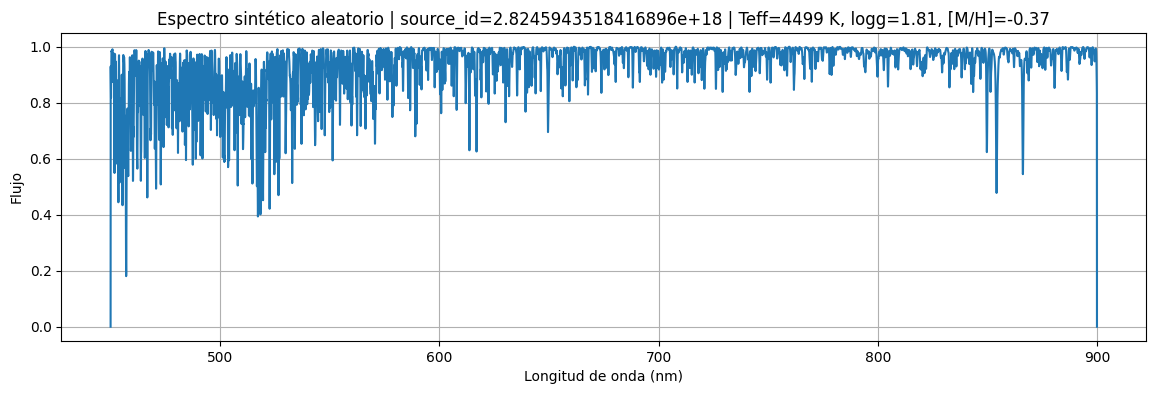

In [13]:
plt.figure(figsize=(14, 4))
plt.plot(wave, flux)

plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Flujo")
plt.title(
    f"Espectro sintético aleatorio | "
    f"source_id={random_row['source_id']} | "
    f"Teff={random_row['teff']:.0f} K, "
    f"logg={random_row['logg']:.2f}, "
    f"[M/H]={random_row['mh']:.2f}"
)

plt.grid(True)
plt.show()

In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
from tqdm.auto import tqdm


def degrade_resolution_constant_R(wave_nm, flux, r_from, r_to):
    wave_nm = np.asarray(wave_nm, dtype=np.float64)
    flux = np.asarray(flux, dtype=np.float64)

    if r_to >= r_from:
        return flux.astype(np.float32)

    delta_lambda = np.median(np.diff(wave_nm))
    lambda_central = np.nanmedian(wave_nm)

    fwhm_from = lambda_central / r_from
    fwhm_to = lambda_central / r_to

    fwhm_kernel = np.sqrt(max(fwhm_to**2 - fwhm_from**2, 0.0))
    sigma_kernel_nm = fwhm_kernel / 2.355
    sigma_kernel_pix = sigma_kernel_nm / delta_lambda

    degraded_flux = gaussian_filter1d(
        flux,
        sigma_kernel_pix,
        mode="nearest"
    )

    return degraded_flux.astype(np.float32)


def resample_spectrum(wave_in, flux_in, wave_out):
    interpolator = interp1d(
        wave_in,
        flux_in,
        kind="linear",
        bounds_error=False,
        fill_value=np.nan
    )

    return interpolator(wave_out).astype(np.float32)


def create_instrument_like_batches(
    high_res_dir,
    output_dir,
    instrument_name,
    r_high,
    r_instrument,
    wave_min,
    wave_max,
    wave_step
):
    high_res_dir = Path(high_res_dir)
    output_dir = Path(output_dir) / instrument_name
    output_dir.mkdir(parents=True, exist_ok=True)

    wave_high = np.load(high_res_dir / "wave_high_nm.npy").astype(np.float64)
    worked_df = pd.read_csv(high_res_dir / "worked_spectra.csv")

    wave_out = np.arange(
        wave_min,
        wave_max + wave_step / 2,
        wave_step,
        dtype=np.float32
    )

    np.save(output_dir / f"wave_{instrument_name}_nm.npy", wave_out)

    print(f"Creando versión {instrument_name}")
    print("R instrumento:", r_instrument)
    print("Rango:", wave_min, "-", wave_max, "nm")
    print("Step:", wave_step, "nm")
    print("Puntos salida:", len(wave_out))

    for batch_id in sorted(worked_df["batch_id"].unique()):
        batch_id = int(batch_id)

        spectra_path = high_res_dir / f"spectra_high_batch_{batch_id:04d}.npy"
        metadata_path = high_res_dir / f"metadata_batch_{batch_id:04d}.csv"

        if not spectra_path.exists():
            continue

        spectra_high = np.load(spectra_path, mmap_mode="r")
        metadata = pd.read_csv(metadata_path)

        spectra_out = []

        print(f"\nProcesando batch {batch_id:04d}")

        for i in tqdm(range(spectra_high.shape[0])):
            flux_high = np.asarray(spectra_high[i], dtype=np.float32)

            degraded_flux = degrade_resolution_constant_R(
                wave_high,
                flux_high,
                r_from=r_high,
                r_to=r_instrument
            )

            resampled_flux = resample_spectrum(
                wave_high,
                degraded_flux,
                wave_out
            )

            spectra_out.append(resampled_flux)

        spectra_out = np.vstack(spectra_out).astype(np.float32)

        np.save(
            output_dir / f"spectra_{instrument_name}_batch_{batch_id:04d}.npy",
            spectra_out
        )

        metadata.to_csv(
            output_dir / f"metadata_{instrument_name}_batch_{batch_id:04d}.csv",
            index=False
        )

        print("Guardado:", spectra_out.shape)

    worked_df.to_csv(output_dir / f"worked_{instrument_name}.csv", index=False)

    return wave_out

In [15]:
wave_sdss = create_instrument_like_batches(
    high_res_dir="data/synthetic_high_res_450_900_raw",
    output_dir="data/synthetic_instruments_450_900",
    instrument_name="sdss_like",
    r_high=2500,
    r_instrument=2000,
    wave_min=450.0,
    wave_max=900.0,
    wave_step=0.1
)

Creando versión sdss_like
R instrumento: 2000
Rango: 450.0 - 900.0 nm
Step: 0.1 nm
Puntos salida: 4501

Procesando batch 0000


  0%|          | 0/9 [00:00<?, ?it/s]

Guardado: (9, 4501)


In [16]:
wave_gaia = create_instrument_like_batches(
    high_res_dir="data/synthetic_high_res_450_900_raw",
    output_dir="data/synthetic_instruments_450_900",
    instrument_name="gaia_like",
    r_high=2500,
    r_instrument=160,
    wave_min=450.0,
    wave_max=900.0,
    wave_step=1.0
)

Creando versión gaia_like
R instrumento: 160
Rango: 450.0 - 900.0 nm
Step: 1.0 nm
Puntos salida: 451

Procesando batch 0000


  0%|          | 0/9 [00:00<?, ?it/s]

Guardado: (9, 451)


In [21]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Carpeta donde están tus espectros de alta resolución
high_res_dir = Path("data/synthetic_high_res_450_900_raw")

# Cargar malla y primer batch
wave_high = np.load(high_res_dir / "wave_high_nm.npy")
spectra_high_batch_0000 = np.load(high_res_dir / "spectra_high_batch_0000.npy")

# Primer espectro del batch 0000
flux_high = spectra_high_batch_0000[0]

print("wave_high:", wave_high.shape)
print("flux_high:", flux_high.shape)

print("Flux high min:", np.nanmin(flux_high))
print("Flux high max:", np.nanmax(flux_high))
print("Flux high median:", np.nanmedian(flux_high))

wave_high: (9001,)
flux_high: (9001,)
Flux high min: 0.0
Flux high max: 0.99950445
Flux high median: 0.9745195


In [ ]:
R_HIGH = 2500
R_SDSS = 2000
R_GAIA = 160

sdss_wave = np.arange(450.0, 900.0, 0.5)
gaia_wave = np.arange(450.0, 900.0, 2.0)

sdss_flux_high_grid = degrade_resolution_constant_R(
    wave_high,
    flux_high,
    r_from=R_HIGH,
    r_to=R_SDSS
)

sdss_flux = resample_spectrum(
    wave_high,
    sdss_flux_high_grid,
    sdss_wave
)

gaia_flux_high_grid = degrade_resolution_constant_R(
    wave_high,
    flux_high,
    r_from=R_HIGH,
    r_to=R_GAIA
)

gaia_flux = resample_spectrum(
    wave_high,
    gaia_flux_high_grid,
    gaia_wave
)

print("Puntos alta resolución:", len(wave_high))
print("Puntos SDSS-like:", len(sdss_wave))
print("Puntos Gaia-like:", len(gaia_wave))

Puntos alta resolución: 9001
Puntos SDSS-like: 900
Puntos Gaia-like: 450


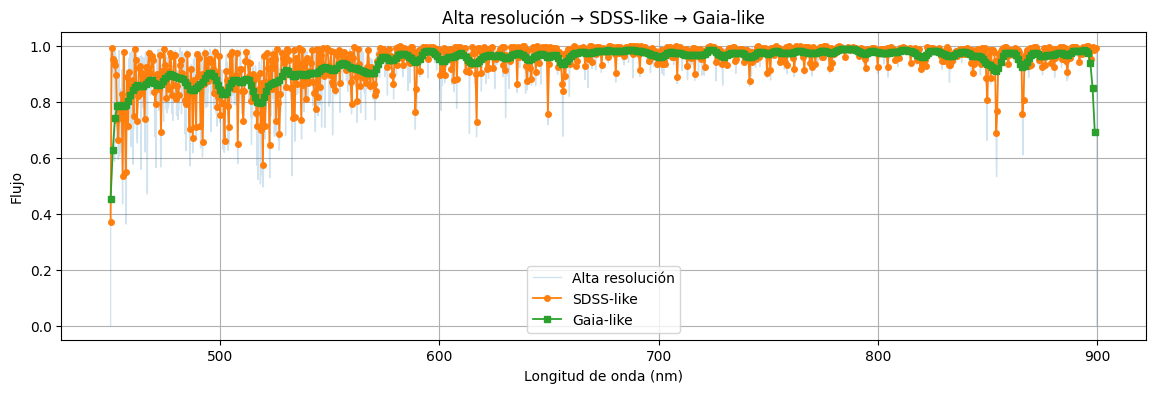

In [29]:
plt.figure(figsize=(14, 4))

plt.plot(
    wave_high,
    flux_high,
    alpha=0.20,
    linewidth=1.0,
    label="Alta resolución"
)

plt.plot(
    sdss_wave,
    sdss_flux,
    marker="o",
    markersize=4,
    linewidth=1.3,
    label="SDSS-like"
)

plt.plot(
    gaia_wave,
    gaia_flux,
    marker="s",
    markersize=4,
    linewidth=1.3,
    label="Gaia-like"
)

plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Flujo")
plt.title("Alta resolución → SDSS-like → Gaia-like")
plt.grid(True)
plt.legend()
plt.show()